### Part A: Scikit-learn Implementation

In [34]:
import numpy as np
import pandas as pd
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# 1. Load and prepare data
df = pd.read_csv("garments_worker_productivity.csv")
df.columns = df.columns.str.strip()

y_reg = df['actual_productivity']
df['Meets_Target'] = (df['actual_productivity'] >= df['targeted_productivity']).astype(int)
y_clf = df['Meets_Target']

X = df.drop(columns=['actual_productivity', 'Meets_Target', 'date'])

num_features = X.select_dtypes(include=['float64', 'int64']).columns.tolist()
cat_features = X.select_dtypes(include=['object']).columns.tolist()

# 2. Preprocessing Pipeline
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers = [
        ('num', num_transformer, num_features),
        ('cat', cat_transformer, cat_features)
    ])

all_indices = np.arange(len(X))

train_idx, test_idx = train_test_split(
    all_indices,
    test_size=0.2,
    random_state=42
)
X_processed = preprocessor.fit_transform(X)
X_train = X_processed[train_idx]
X_test = X_processed[test_idx]

y_reg_train = y_reg.iloc[train_idx].values
y_reg_test = y_reg.iloc[test_idx].values

y_clf_train = y_clf.iloc[train_idx].values
y_clf_test = y_clf.iloc[test_idx].values

print("--- Part A: Scikit-Learn Implementation ---\n")

# 3. Linear Regression (Scikit-Learn)
lin_reg = LinearRegression()

start_train_reg = time.time()
lin_reg.fit(X_train, y_reg_train)
train_time_reg_sk = time.time() - start_train_reg

start_pred_reg = time.time()
y_reg_pred = lin_reg.predict(X_test)
pred_time_reg_sk = time.time() - start_pred_reg

mae_sk = mean_absolute_error(y_reg_test, y_reg_pred)
rmse_sk = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
r2_sk = r2_score(y_reg_test, y_reg_pred)

print("Linear Regression Results:")
print(f"Training Time:   {train_time_reg_sk:.6f} seconds")
print(f"Prediction Time: {pred_time_reg_sk:.6f} seconds")
print(f"MAE:  {mae_sk:.4f}")
print(f"RMSE: {rmse_sk:.4f}")
print(f"R2:   {r2_sk:.4f}\n")

# 4. Logistic Regression (Scikit-Learn)
log_reg = LogisticRegression(max_iter=1000)

start_train_clf = time.time()
log_reg.fit(X_train, y_clf_train)
train_time_clf_sk = time.time() - start_train_clf

start_pred_clf = time.time()
y_clf_pred = log_reg.predict(X_test)
pred_time_clf_sk = time.time() - start_pred_clf

acc_sk = accuracy_score(y_clf_test, y_clf_pred)
prec_sk = precision_score(y_clf_test, y_clf_pred)
rec_sk = recall_score(y_clf_test, y_clf_pred)
f1_sk = f1_score(y_clf_test, y_clf_pred)

print("Logistic Regression Results:")
print(f"Training Time:   {train_time_clf_sk:.6f} seconds")
print(f"Prediction Time: {pred_time_clf_sk:.6f} seconds")
print(f"Accuracy:  {acc_sk:.4f}")
print(f"Precision: {prec_sk:.4f}")
print(f"Recall:    {rec_sk:.4f}")
print(f"F1-Score:  {f1_sk:.4f}")

--- Part A: Scikit-Learn Implementation ---

Linear Regression Results:
Training Time:   0.003208 seconds
Prediction Time: 0.000115 seconds
MAE:  0.1085
RMSE: 0.1486
R2:   0.1682

Logistic Regression Results:
Training Time:   0.013556 seconds
Prediction Time: 0.000501 seconds
Accuracy:  0.7750
Precision: 0.7808
Recall:    0.9661
F1-Score:  0.8636


### Part B: Manual - From Scratch Implementation

In [35]:
df = pd.read_csv("garments_worker_productivity.csv")
df.columns = df.columns.str.strip()

y_reg_raw = df['actual_productivity'].values
y_clf_raw = (df['actual_productivity'] >= df['targeted_productivity']).astype(int).values
X_raw = df.drop(columns=['actual_productivity', 'date'])

X_train_raw = X_raw.iloc[train_idx].copy()
X_test_raw = X_raw.iloc[test_idx].copy()
y_reg_train = y_reg_raw[train_idx]
y_reg_test = y_reg_raw[test_idx]
y_clf_train = y_clf_raw[train_idx]
y_clf_test = y_clf_raw[test_idx]

num_cols = X_train_raw.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train_raw.select_dtypes(include=['object']).columns

# A. Missing Value Handling (Fit on train, apply to both)
medians = X_train_raw[num_cols].median()
X_train_raw[num_cols] = X_train_raw[num_cols].fillna(medians)
X_test_raw[num_cols] = X_test_raw[num_cols].fillna(medians)

X_train_raw[cat_cols] = X_train_raw[cat_cols].fillna('missing')
X_test_raw[cat_cols] = X_test_raw[cat_cols].fillna('missing')

# B. Categorical Encoding (One-Hot Encoding via pandas)
X_train_ohe = pd.get_dummies(X_train_raw, columns=cat_cols)
X_test_ohe = pd.get_dummies(X_test_raw, columns=cat_cols)
X_train_ohe, X_test_ohe = X_train_ohe.align(X_test_ohe, join='left', axis=1, fill_value=0)

# C. Feature Scaling (Standardization: (X - mean) / std)
means = X_train_ohe[num_cols].mean()
stds = X_train_ohe[num_cols].std(ddof=0)
stds[stds == 0] = 1 # Prevent division by zero

X_train_ohe[num_cols] = (X_train_ohe[num_cols] - means) / stds
X_test_ohe[num_cols] = (X_test_ohe[num_cols] - means) / stds

X_train_mat = X_train_ohe.to_numpy(dtype=float)
X_test_mat = X_test_ohe.to_numpy(dtype=float)

X_train_mat = np.c_[np.ones(X_train_mat.shape[0]), X_train_mat]
X_test_mat = np.c_[np.ones(X_test_mat.shape[0]), X_test_mat]

def calc_mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def calc_rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

def calc_r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - (ss_res / ss_tot)

def calc_clf_metrics(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    
    accuracy = (tp + tn) / len(y_true)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    return accuracy, precision, recall, f1

print("--- PART B: FROM-SCRATCH IMPLEMENTATION ---\n")

class ManualLinearRegression:
    def fit(self, X, y):
        self.theta = np.linalg.pinv(X.T @ X) @ X.T @ y
        
    def predict(self, X):
        return X @ self.theta

manual_lin_reg = ManualLinearRegression()

start_train_reg = time.time()
manual_lin_reg.fit(X_train_mat, y_reg_train)
train_time_reg_man = time.time() - start_train_reg

start_pred_reg = time.time()
y_reg_pred_manual = manual_lin_reg.predict(X_test_mat)
pred_time_reg_man = time.time() - start_pred_reg

# Store metrics to match Part C
mae_man = calc_mae(y_reg_test, y_reg_pred_manual)
rmse_man = calc_rmse(y_reg_test, y_reg_pred_manual)
r2_man = calc_r2(y_reg_test, y_reg_pred_manual)

print("Manual Linear Regression Results:")
print(f"Training Time:   {train_time_reg_man:.6f} seconds")
print(f"Prediction Time: {pred_time_reg_man:.6f} seconds")
print(f"MAE:  {mae_man:.4f}")
print(f"RMSE: {rmse_man:.4f}")
print(f"R2:   {r2_man:.4f}\n")

class ManualLogisticRegression:
    def __init__(self, lr=0.1, max_iter=2000):
        self.lr = lr
        self.max_iter = max_iter
        
    def sigmoid(self, z):
        z = np.clip(z, -250, 250)
        return 1 / (1 + np.exp(-z))
        
    def fit(self, X, y):
        m, n = X.shape
        self.theta = np.zeros(n)
        for _ in range(self.max_iter):
            h = self.sigmoid(X @ self.theta)
            gradient = (1 / m) * X.T @ (h - y)
            self.theta -= self.lr * gradient
            
    def predict_proba(self, X):
        return self.sigmoid(X @ self.theta)
        
    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

manual_log_reg = ManualLogisticRegression(lr=0.1, max_iter=2000)

start_train_clf = time.time()
manual_log_reg.fit(X_train_mat, y_clf_train)
train_time_clf_man = time.time() - start_train_clf

start_pred_clf = time.time()
y_clf_pred_manual = manual_log_reg.predict(X_test_mat)
pred_time_clf_man = time.time() - start_pred_clf

# Store metrics to match Part C
acc_man, prec_man, rec_man, f1_man = calc_clf_metrics(y_clf_test, y_clf_pred_manual)

print("Manual Logistic Regression Results:")
print(f"Training Time:   {train_time_clf_man:.6f} seconds")
print(f"Prediction Time: {pred_time_clf_man:.6f} seconds")
print(f"Accuracy:  {acc_man:.4f}")
print(f"Precision: {prec_man:.4f}")
print(f"Recall:    {rec_man:.4f}")
print(f"F1-Score:  {f1_man:.4f}")

--- PART B: FROM-SCRATCH IMPLEMENTATION ---

Manual Linear Regression Results:
Training Time:   0.001001 seconds
Prediction Time: 0.000000 seconds
MAE:  0.1085
RMSE: 0.1486
R2:   0.1682

Manual Logistic Regression Results:
Training Time:   0.208875 seconds
Prediction Time: 0.000349 seconds
Accuracy:  0.7750
Precision: 0.7808
Recall:    0.9661
F1-Score:  0.8636


### Part C:  Comparison and Optimization

In [36]:
comparison_data = {

    "Model": [
        "Linear Regression (Scikit-learn)",
        "Linear Regression (Manual)",
        "Logistic Regression (Scikit-learn)",
        "Logistic Regression (Manual)"
    ],

    "Train Time (s)": [
        train_time_reg_sk,
        train_time_reg_man,
        train_time_clf_sk,
        train_time_clf_man
    ],

    "Prediction Time (s)": [
        pred_time_reg_sk,
        pred_time_reg_man,
        pred_time_clf_sk,
        pred_time_clf_man
    ],

    "MAE": [
        mae_sk,
        mae_man,
        np.nan,
        np.nan
    ],

    "RMSE": [
        rmse_sk,
        rmse_man,
        np.nan,
        np.nan
    ],

    "R2": [
        r2_sk,
        r2_man,
        np.nan,
        np.nan
    ],

    "Accuracy": [
        np.nan,
        np.nan,
        acc_sk,
        acc_man
    ],

    "Precision": [
        np.nan,
        np.nan,
        prec_sk,
        prec_man
    ],

    "Recall": [
        np.nan,
        np.nan,
        rec_sk,
        rec_man
    ],

    "F1-Score": [
        np.nan,
        np.nan,
        f1_sk,
        f1_man
    ]
}

comparison_df = pd.DataFrame(comparison_data)

print("\n===== COMPLETE COMPARISON =====")

display(
    comparison_df.round(6)
)


===== COMPLETE COMPARISON =====


,Model,Train Time (s),Prediction Time (s),MAE,RMSE,R2,Accuracy,Precision,Recall,F1-Score
0,Linear Regression (Scikit-learn),0.003208,0.000115,0.108453,0.148618,0.168168,NaN,NaN,NaN,NaN
1,Linear Regression (Manual),0.001001,0.000000,0.108453,0.148618,0.168168,NaN,NaN,NaN,NaN
2,Logistic Regression (Scikit-learn),0.013556,0.000501,NaN,NaN,NaN,0.775,0.780822,0.966102,0.863636
3,Logistic Regression (Manual),0.208875,0.000349,NaN,NaN,NaN,0.775,0.780822,0.966102,0.863636


In [ ]:

learning_rates = [
    0.001,
    0.01,
    0.05,
    0.1,
    0.2,
    0.5,
    1.0
]

lr_results = []

for lr in learning_rates:

    model = ManualLogisticRegression(
        lr=lr,
        max_iter=2000
    )

    # Training time
    start = time.perf_counter()

    model.fit(
        X_train_mat,
        y_clf_train
    )

    train_time = time.perf_counter() - start

    # Prediction time
    start = time.perf_counter()

    predictions = model.predict(
        X_test_mat
    )

    prediction_time = time.perf_counter() - start

    # Metrics
    accuracy, precision, recall, f1 = calc_clf_metrics(
        y_clf_test,
        predictions
    )

    lr_results.append({

        "Learning Rate": lr,
        "Training Time": train_time,
        "Prediction Time": prediction_time,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })


lr_df = pd.DataFrame(lr_results)

print("===== LEARNING RATE EXPERIMENT =====")

display(
    lr_df.round(6)
)

===== LEARNING RATE EXPERIMENT =====


,Learning Rate,Training Time,Prediction Time,Accuracy,Precision,Recall,F1-Score
0,0.001,0.180064,0.000049,0.741667,0.740586,1.000000,0.850962
1,0.010,0.107811,0.000030,0.750000,0.748936,0.994350,0.854369
2,0.050,0.109433,0.000028,0.775000,0.778281,0.971751,0.864322
3,0.100,0.105441,0.000040,0.775000,0.780822,0.966102,0.863636
4,0.200,0.104031,0.000047,0.775000,0.783410,0.960452,0.862944
5,0.500,0.103113,0.000045,0.775000,0.783410,0.960452,0.862944
6,1.000,0.106583,0.000035,0.775000,0.783410,0.960452,0.862944


In [38]:
best_index = lr_df["F1-Score"].idxmax()

best_lr = lr_df.loc[
    best_index,
    "Learning Rate"
]

print("Best Learning Rate:", best_lr)

print(
    lr_df.loc[
        best_index
    ].round(6)
)

Best Learning Rate: 0.05
Learning Rate      0.050000
Training Time      0.109433
Prediction Time    0.000028
Accuracy           0.775000
Precision          0.778281
Recall             0.971751
F1-Score           0.864322
Name: 2, dtype: float64


In [39]:
optimized_log_reg = ManualLogisticRegression(
    lr=best_lr,
    max_iter=2000
)

start = time.perf_counter()

optimized_log_reg.fit(
    X_train_mat,
    y_clf_train
)

optimized_train_time = (
    time.perf_counter() - start
)

start = time.perf_counter()

optimized_pred = optimized_log_reg.predict(
    X_test_mat
)

optimized_prediction_time = (
    time.perf_counter() - start
)


(
    optimized_acc,
    optimized_prec,
    optimized_rec,
    optimized_f1
) = calc_clf_metrics(
    y_clf_test,
    optimized_pred
)


print("===== OPTIMIZED MANUAL LOGISTIC REGRESSION =====")

print(f"Learning Rate : {best_lr}")
print(f"Training Time : {optimized_train_time:.6f}")
print(f"Prediction Time: {optimized_prediction_time:.6f}")
print(f"Accuracy      : {optimized_acc:.4f}")
print(f"Precision     : {optimized_prec:.4f}")
print(f"Recall        : {optimized_rec:.4f}")
print(f"F1-Score      : {optimized_f1:.4f}")

===== OPTIMIZED MANUAL LOGISTIC REGRESSION =====
Learning Rate : 0.05
Training Time : 0.144554
Prediction Time: 0.000085
Accuracy      : 0.7750
Precision     : 0.7783
Recall        : 0.9718
F1-Score      : 0.8643


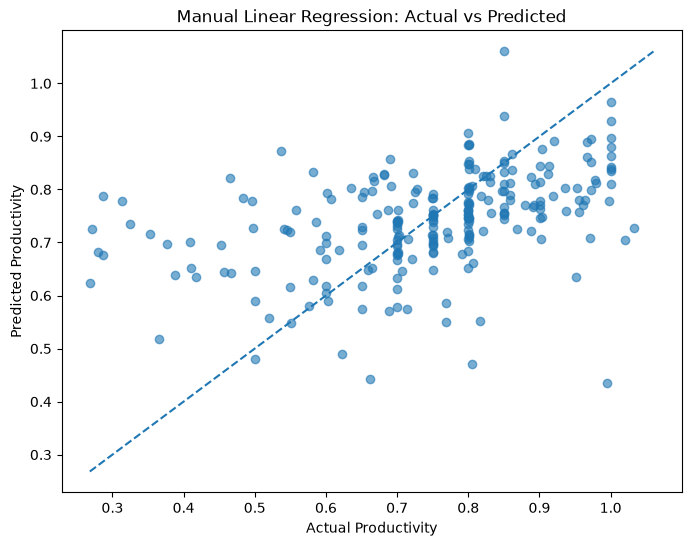

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(
    y_reg_test,
    y_reg_pred_manual,
    alpha=0.6
)

plt.xlabel("Actual Productivity")
plt.ylabel("Predicted Productivity")
plt.title(
    "Manual Linear Regression: Actual vs Predicted"
)

min_val = min(
    y_reg_test.min(),
    y_reg_pred_manual.min()
)

max_val = max(
    y_reg_test.max(),
    y_reg_pred_manual.max()
)

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--"
)

plt.show()

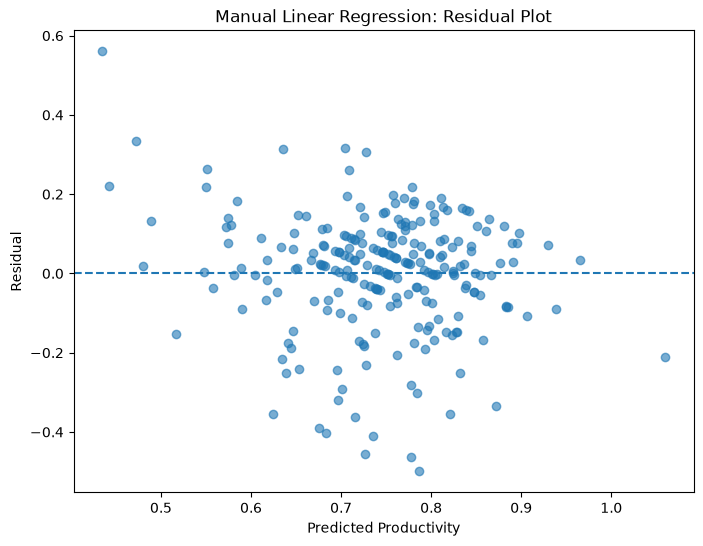

In [41]:
residuals = (
    y_reg_test - y_reg_pred_manual
)

plt.figure(figsize=(8, 6))

plt.scatter(
    y_reg_pred_manual,
    residuals,
    alpha=0.6
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Productivity")
plt.ylabel("Residual")
plt.title(
    "Manual Linear Regression: Residual Plot"
)
plt.show()

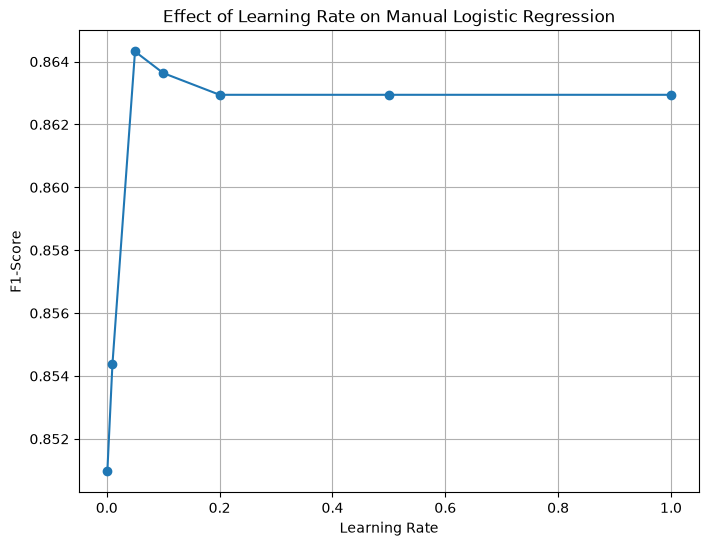

In [42]:
plt.figure(figsize=(8, 6))

plt.plot(
    lr_df["Learning Rate"],
    lr_df["F1-Score"],
    marker="o"
)

plt.xlabel("Learning Rate")
plt.ylabel("F1-Score")

plt.title(
    "Effect of Learning Rate on Manual Logistic Regression"
)

plt.grid(True)

plt.show()

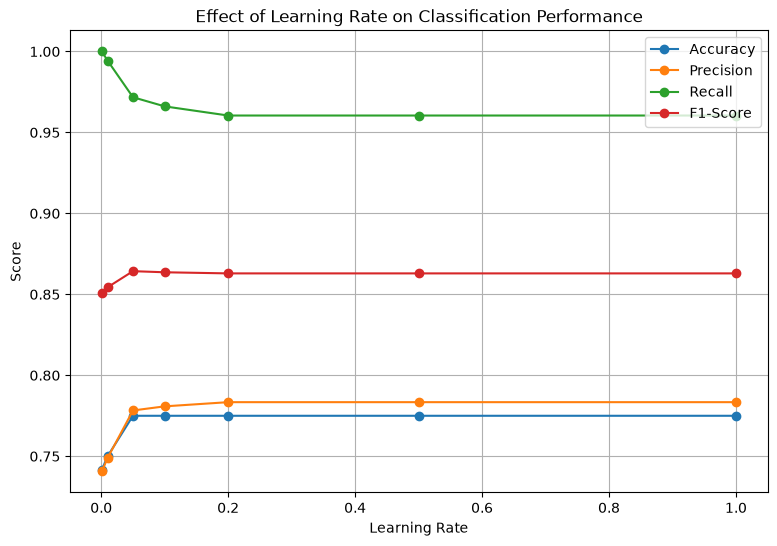

In [43]:
plt.figure(figsize=(9, 6))

plt.plot(
    lr_df["Learning Rate"],
    lr_df["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    lr_df["Learning Rate"],
    lr_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    lr_df["Learning Rate"],
    lr_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    lr_df["Learning Rate"],
    lr_df["F1-Score"],
    marker="o",
    label="F1-Score"
)

plt.xlabel("Learning Rate")
plt.ylabel("Score")

plt.title(
    "Effect of Learning Rate on Classification Performance"
)

plt.legend()
plt.grid(True)

plt.show()